In [2]:
import os
import tarfile
import matplotlib.pyplot as plt
import numpy as np
import requests
import scipy
from PIL import Image
from torch.utils.data import Dataset, Subset, random_split, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

import helper_utils

In [4]:
def download_dataset():
    """
    Downloads and extracts a dataset from remote URLs if not already present locally.

    This function first checks for the existence of the dataset files in a specific
    directory. If the files are not found, it proceeds to download them from
    pre-defined URLs, and then extracts the contents.
    """
    # Define the directory to store the dataset.
    data_dir = "flower_data"
    
    # Define paths for key files and folders.
    image_folder_path = os.path.join(data_dir, "jpg")
    labels_file_path = os.path.join(data_dir, "imagelabels.mat")
    tgz_path = os.path.join(data_dir, "102flowers.tgz")

    # Check if the primary data folder and a key label file already exist.
    if os.path.exists(image_folder_path) and os.path.exists(labels_file_path):
        # Inform the user that the dataset is already available locally.
        print(f"Dataset already exists. Loading locally from '{data_dir}'.")
        # Exit the function since no download is needed.
        return

    # Inform the user that the dataset is not found and the download will start.
    print("Dataset not found locally. Downloading...")

    # Define the URLs for the image archive and the labels file.
    image_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz"
    labels_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat"

    # Create the target directory for the dataset, if it doesn't already exist.
    os.makedirs(data_dir, exist_ok=True)

    # Announce the start of the image download process.
    print("Downloading images...")
    # Send an HTTP GET request to the image URL, enabling streaming for large files.
    response = requests.get(image_url, stream=True)
    # Get the total size of the file from the response headers for the progress bar.
    total_size = int(response.headers.get("content-length", 0))

    # Open a local file in binary write mode to save the downloaded archive.
    with open(tgz_path, "wb") as file:
        # Iterate over the response content in chunks with a progress bar.
        for data in tqdm(
            # Define the chunk size for iterating over the content.
            response.iter_content(chunk_size=1024),
            # Set the total for the progress bar based on the file size in kilobytes.
            total=total_size // 1024,
        ):
            # Write each chunk of data to the file.
            file.write(data)

    # Announce the start of the file extraction process.
    print("Extracting files...")
    # Open the downloaded tar.gz archive in read mode.
    with tarfile.open(tgz_path, "r:gz") as tar:
        # Extract all contents of the archive into the target directory.
        tar.extractall(data_dir)

    # Announce the start of the labels download process.
    print("Downloading labels...")
    # Send an HTTP GET request to the labels URL.
    response = requests.get(labels_url)
    # Open a local file in binary write mode to save the labels.
    with open(labels_file_path, "wb") as file:
        # Write the entire content of the response to the file.
        file.write(response.content)

    # Inform the user that the download and extraction are complete.
    print(f"Dataset downloaded and extracted to '{data_dir}'.")

    # create labels_description.txt
    labels_description = [
        'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily',
        'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea',
        'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
        'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth',
        'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation',
        'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower',
        'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
        'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia',
        'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
        'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy',
        'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily',
        'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
        'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen ', 'watercress',
        'canna lily', 'hippeastrum ', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow',
        'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily'
    ]

    with open(os.path.join(data_dir, "labels_description.txt"), "w") as f:
        for idx, label in enumerate(labels_description, start=1):
            f.write(f"{label}\n")

In [5]:
# Call the function to download and prepare the dataset.
download_dataset()

Dataset not found locally. Downloading...


336780it [00:43, 7767.20it/s]                             


Extracting files...
Dataset downloaded and extracted to 'flower_data'.


In [6]:
# Define the path to the root directory of the dataset.
path_dataset = './flower_data'

# Display the folder structure of the dataset directory up to a depth of one.
helper_utils.print_data_folder_structure(path_dataset, max_depth=1)

flower_data/
├── 102flowers.tgz
├── imagelabels.mat
├── jpg/
└── labels_description.txt


In [7]:
class FlowerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_dir = os.path.join(self.root_dir, "jpg")
        self.labels = self.load_and_correct_labels()

    def __len__(self):
        total_samples = len(self.labels)
        return total_samples
    
    def __getitem__(self, idx):
        image = self.retrieve_image(idx)
        if self.transform is not None:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label
    
    def retrieve_image(self, idx):
        img_name = f"image_{idx+1:05d}.jpg"
        img_path = os.path.join(self.image_dir, img_name)
        with Image.open(img_path) as img:
            image = img.convert("RGB")
        return image
    
    def load_and_correct_labels(self):
        self.labels_mat = scipy.io.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )

        labels = self.labels_mat["labels"][0]-1

        return labels

    def get_label_description(self, label):
        path_labels_description = os.path.join(self.root_dir, "labels_description.txt")
        with open(path_labels_description, "r") as f:
            lines = f.readlines()
        description = lines[label].strip()
        return description

In [8]:
dataset = FlowerDataset(path_dataset)

In [9]:
# Print the total number of samples in the dataset.
print(f'Number of samples in the dataset: {len(dataset)}')

Number of samples in the dataset: 8189


In [10]:
# Define an index for a sample to retrieve.
sel_idx = 10

# Retrieve the image and label for the selected index.
img, label = dataset[sel_idx]

In [11]:
# Create a string detailing the image's dimensions.
img_size_info = f"Image size: {img.size}"

# Print the image size information along with its corresponding label.
print(f'{img_size_info}, Label: {label}')

Image size: (500, 748), Label: 76


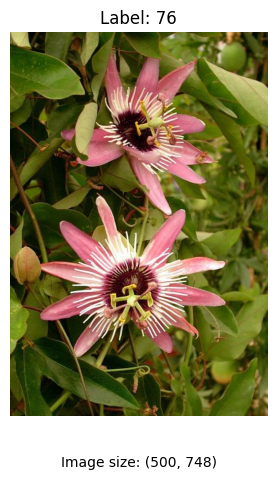

In [12]:
helper_utils.plot_img(img, label=label, info=img_size_info)

In [13]:
# Get all labels from the dataset object.
dataset_labels = dataset.labels

# Create a set of unique labels to remove duplicates.
unique_labels = set(dataset_labels)

# Iterate through each unique label.
for label in unique_labels:
    # Print the numerical label and its corresponding text description.
    print(f'Label: {label}, Description: {dataset.get_label_description(label)}')

Label: 0, Description: pink primrose
Label: 1, Description: hard-leaved pocket orchid
Label: 2, Description: canterbury bells
Label: 3, Description: sweet pea
Label: 4, Description: english marigold
Label: 5, Description: tiger lily
Label: 6, Description: moon orchid
Label: 7, Description: bird of paradise
Label: 8, Description: monkshood
Label: 9, Description: globe thistle
Label: 10, Description: snapdragon
Label: 11, Description: colt's foot
Label: 12, Description: king protea
Label: 13, Description: spear thistle
Label: 14, Description: yellow iris
Label: 15, Description: globe-flower
Label: 16, Description: purple coneflower
Label: 17, Description: peruvian lily
Label: 18, Description: balloon flower
Label: 19, Description: giant white arum lily
Label: 20, Description: fire lily
Label: 21, Description: pincushion flower
Label: 22, Description: fritillary
Label: 23, Description: red ginger
Label: 24, Description: grape hyacinth
Label: 25, Description: corn poppy
Label: 26, Descript

In [14]:
def visual_exploration(dataset, num_rows=2, num_cols=4):
    """
    Displays a grid of randomly selected samples from a dataset for visual inspection.

    Args:
        dataset (Dataset): The dataset object from which to draw samples. It should support
            indexing and have a `get_label_description` method.
        num_rows (int): The number of rows in the display grid.
        num_cols (int): The number of columns in the display grid.
    """
    # Calculate the total number of images to display in the grid.
    total_samples = num_rows * num_cols

    # Select a random set of unique indices from the dataset.
    indices = np.random.choice(len(dataset), total_samples, replace=False)

    # Create a grid of subplots to hold the images.
    fig, axes = helper_utils.get_grid(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 4))

    # Iterate over each subplot axis and the corresponding random sample index.
    for ax, idx in zip(axes.flatten(), indices):
        # Retrieve the image and its numerical label from the dataset.
        image, label = dataset[idx]

        # Get the human-readable text description for the label.
        description = dataset.get_label_description(label)

        # Format a new label string that includes both the number and description.
        label = f"{label} - {description}"

        # Create an information string with the sample's index and image dimensions.
        info = f"Index: {idx} Size: {image.size}"
        
        # Plot the image on the current subplot with its label and info.
        helper_utils.plot_img(image, label=label, info=info, ax=ax)

    # Render and display the entire grid of images.
    plt.show()

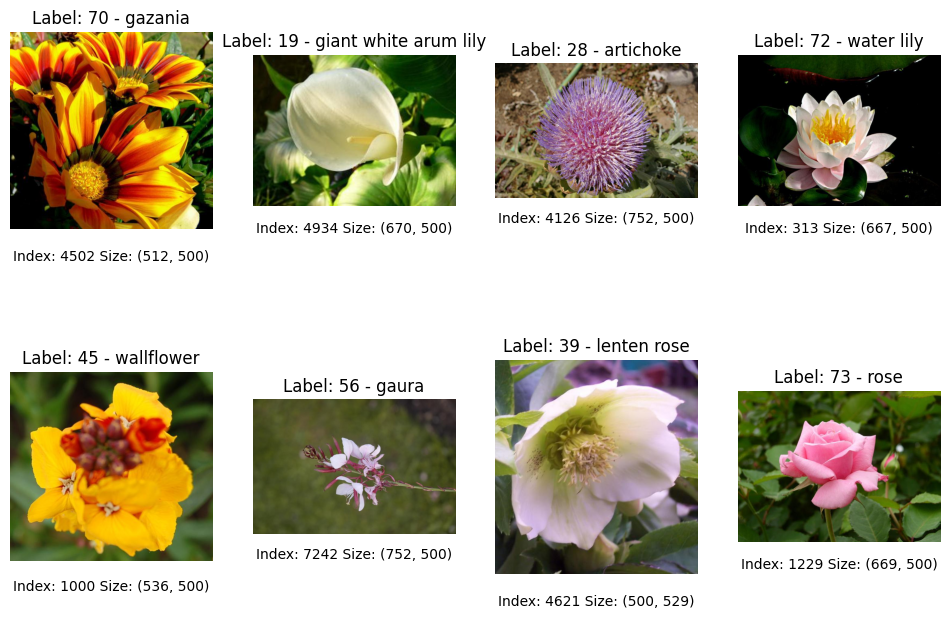

In [15]:
# Display a 2x4 grid of random samples from the dataset for visual inspection.
visual_exploration(dataset, num_rows=2, num_cols=4)

### Quality Problem

In [16]:
# Define the mean values for normalization.
mean = [0.485, 0.456, 0.406]
# Define the standard deviation values for normalization.
std = [0.229, 0.224, 0.225]

In [17]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),

    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [18]:
dataset_transformed = FlowerDataset(path_dataset, transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


Shape: torch.Size([3, 224, 224])
Type: torch.float32
Range of pixel values: [-2.1, 2.6]


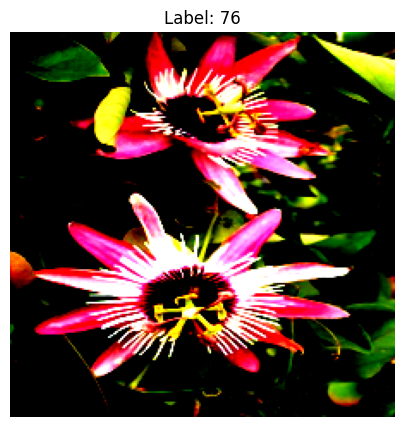

In [19]:
img_transformed, label = dataset_transformed[sel_idx]

helper_utils.quick_debug(img_transformed)

helper_utils.plot_img(img_transformed, label=label)

In [20]:
class Denormalize:
    """
    A callable class to reverse the normalization of a tensor image.

    This class calculates the inverse transformation of a standard normalization
    and can be used as a transform step, for instance, to visualize images
    after they have been normalized for a model.
    """
    def __init__(self, mean, std):
        """
        Initializes the denormalization transform.

        Args:
            mean (list or tuple): The mean values used for the original normalization.
            std (list or tuple): The standard deviation values used for the original normalization.
        """
        # Calculate the adjusted mean for the denormalization process.
        new_mean = [-m / s for m, s in zip(mean, std)]
        # Calculate the adjusted standard deviation for the denormalization process.
        new_std = [1 / s for s in std]
        # Create a Normalize transform object with the inverse parameters.
        self.denormalize = transforms.Normalize(mean=new_mean, std=new_std)

    def __call__(self, tensor):
        """
        Applies the denormalization transform to a tensor.

        Args:
            tensor (torch.Tensor): The normalized tensor to be denormalized.

        Returns:
            denormalized_tensor (torch.Tensor): The denormalized tensor.
        """
        # Apply the denormalization transform to the input tensor.
        denormalized_tensor = self.denormalize(tensor)
        
        # Return the denormalized tensor.
        return denormalized_tensor

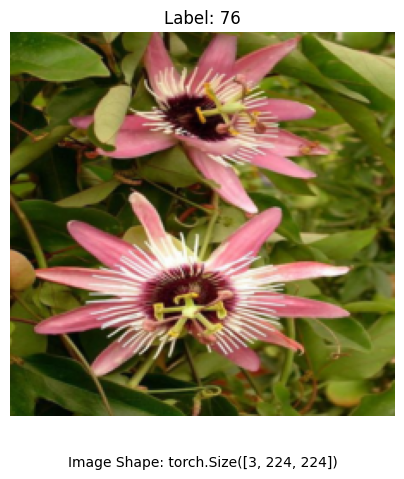

In [21]:
# Create an instance of the Denormalize class with the original mean and std.
denormalize = Denormalize(mean=mean, std=std)
# Apply the denormalization transform to the image tensor.
img_tensor = denormalize(img_transformed)

# Create an information string with the tensor's shape.
img_shape_info = f"Image Shape: {img_tensor.size()}"
# Plot the denormalized image to visualize the result.
helper_utils.plot_img(img_tensor, label=label, info=img_shape_info)

### Data Loading

In [23]:
def split_dataset(dataset, val_fraction = 0.15, test_fraction = 0.15):
    total_size = len(dataset)
    val_size = int(total_size * val_fraction)
    test_size = int(total_size * test_fraction)
    train_size = total_size - val_size - test_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size]
    )

    return train_dataset, val_dataset, test_dataset

In [24]:
class SubsetWithTransform(Dataset):
    """
    A wrapper for a PyTorch Subset that applies a specific transformation.

    This class allows for applying a different set of transformations to a
    subset of a dataset, which is useful for creating distinct training,
    validation, or test sets with different preprocessing steps from the
    same base dataset.
    """
    def __init__(self, subset, transform=None):
        """
        Initializes the SubsetWithTransform object.

        Args:
            subset (torch.utils.data.Subset): A PyTorch Subset object containing a portion of a dataset.
            transform (callable, optional): An optional transform to be applied
                to the samples within this subset.
        """
        # Store the original subset of the dataset.
        self.subset = subset
        # Store the transformations to be applied.
        self.transform = transform

    def __len__(self):
        """
        Returns the total number of samples in the subset.

        Returns:
            subset_length (int): The total number of items in the subset.
        """
        # Calculate the length of the underlying subset.
        subset_length = len(self.subset)
        # Return the calculated length.
        return subset_length

    def __getitem__(self, idx):
        """
        Retrieves a sample and applies the transform.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            image (torch.Tensor or PIL.Image.Image): The transformed image.
            label (int): The corresponding label for the image.
        """
        # Get the original image and label from the underlying subset.
        image, label = self.subset[idx]
        
        # Check if a transform has been provided.
        if self.transform:
            # Apply the transform to the image.
            image = self.transform(image)
            
        # Return the transformed image and its label.
        return image, label

In [25]:
# Initialize the base dataset WITHOUT any transforms (returns PIL Images)
dataset_raw = FlowerDataset(path_dataset, transform=None)

# Split the raw dataset
train_subset, val_subset, test_subset = split_dataset(dataset_raw)

In [26]:
# Apply the basic preprocessing transform to all subsets for our initial baseline
train_dataset = SubsetWithTransform(train_subset, transform=transform)
val_dataset = SubsetWithTransform(val_subset, transform=transform)
test_dataset = SubsetWithTransform(test_subset, transform=transform)

In [27]:
print(f"Length of training dataset:   {len(train_dataset)}")
print(f"Length of validation dataset: {len(val_dataset)}")
print(f"Length of test dataset:       {len(test_dataset)}")

Length of training dataset:   5733
Length of validation dataset: 1228
Length of test dataset:       1228


### Data Loader

In [33]:
batch_size = 32

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=batch_size,
                              shuffle=True)

val_dataloader = DataLoader(dataset=val_dataset,
                            batch_size=batch_size,
                            shuffle=False)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=batch_size,
                             shuffle=False)

In [34]:
n_epochs = 2

In [35]:
# Start the main training loop for each epoch.
for epoch in range(n_epochs):
    # Print a header to indicate the start of a new epoch.
    print(f"\n=== Processing epoch {epoch} ===")

    # Announce the start of the training phase.
    print(f"Pass number {epoch} through the training set")
    print('\nTraining...')
    # Get the total number of samples in the training set.
    train_samples = len(train_dataset)
    # Create a progress bar for the training data loader.
    train_bar = helper_utils.get_dataloader_bar(train_dataloader, color='blue')
    
    # Iterate over the training data loader to get batches of images and labels.
    for batch, (images, labels) in enumerate(train_dataloader):
        # Update the training progress bar for the current batch.
        helper_utils.update_dataloader_bar(train_bar, batch, batch_size, train_samples)

    # Announce the start of the validation phase.
    print(f"\nPass number {epoch} through the validation set")
    print('\nValidation...')
    # Create a progress bar for the validation data loader.
    val_bar = helper_utils.get_dataloader_bar(val_dataloader, color='orange')
    # Get the total number of samples in the validation set.
    val_samples = len(val_dataset)
    
    # Iterate over the validation data loader to get batches of images and labels.
    for batch, (images, labels) in enumerate(val_dataloader):
        # Update the validation progress bar for the current batch.
        helper_utils.update_dataloader_bar(val_bar, batch, batch_size, val_samples)

print("\nTraining finished!\n")


=== Processing epoch 0 ===
Pass number 0 through the training set

Training...

Batch 180:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             , 5733 of a total of  5733 samples















































d:\workspace\pytorch-for-dl\.venv\Lib\site-packages\tqdm\std.py:161: TqdmWarning: Unknown colour (orange); valid choices: [hex (#00ff00), BLACK, RED, GREEN, YELLOW, BLUE, MAGENTA, CYAN, WHITE]
  self.colour = colour


Batch 32:  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                               , 1024 of a total of  1228 samples
Batch 39:                                                                                                                                                                                                                                                                                                                                                                                           , 1228 of a total of  1228 samples
=== Processing epoch 1 ===
Pass number 1 through the training set

Training...
Batch 180:                                                                 

In [36]:
# Announce the final evaluation on the test set.
print("Final pass through the test set for evaluation:\n")
# Create a progress bar for the test data loader.
test_bar = helper_utils.get_dataloader_bar(test_dataloader, color='green')
# Get the total number of samples in the test set.
test_samples = len(test_dataset)

# Iterate over the test data loader to get batches of images and labels.
for batch, (images, labels) in enumerate(test_dataloader):
    # Update the test progress bar for the current batch.
    helper_utils.update_dataloader_bar(test_bar, batch, batch_size, test_samples)

print("\nEvaluation finished!\n")    

Final pass through the test set for evaluation:

Batch 35:  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                                  , 1120 of a total of  1228 samples
Batch 39:                                                                                                                                                                                                                                                                                                                                                                                           , 1228 of a total of  1228 samples
Evaluation finished!



### Augmentation

In [37]:
def get_augmentation_transform(mean, std):
    """
    Creates and returns a composition of image transformations for data augmentation
    and preprocessing.

    Args:
        mean (list or tuple): A sequence of mean values for each channel.
        std (list or tuple): A sequence of standard deviation values for each channel.
    
    Returns:
        transform (torchvision.transforms.Compose): A composed pipeline of transformations.
    """
    # Define a list of data augmentation transformations to be applied randomly.
    augmentations_transforms = [
        # Randomly flip the image horizontally with a 50% probability.
        transforms.RandomHorizontalFlip(p=0.5),
        # Randomly rotate the image within a range of +/- 10 degrees.
        transforms.RandomRotation(degrees=10),
        # Randomly adjust the brightness of the image.
        transforms.ColorJitter(brightness=0.2),
    ]
    
    # Define the main list of standard, non-random transformations.
    main_transforms = [
        # Resize the input image to 256x256 pixels.
        transforms.Resize((256, 256)),
        # Crop the center 224x224 pixels of the image.
        transforms.CenterCrop(224),
        # Convert the PIL Image to a PyTorch tensor.
        transforms.ToTensor(),
        # Normalize the tensor with the provided mean and standard deviation.
        transforms.Normalize(mean=mean, std=std),
    ]

    # Combine the augmentation and main transformations into a single pipeline.
    transform = transforms.Compose(augmentations_transforms + main_transforms)
    
    # Return the final composed transform object.
    return transform

In [38]:
# Create the augmentation and preprocessing pipeline, providing the normalization stats.
augmentation_transform = get_augmentation_transform(mean=mean, std=std)

# Initialize a new dataset instance that will use the augmentation pipeline.
dataset_augmented = FlowerDataset(path_dataset, transform=augmentation_transform)

Batch 39:                                                                                                                                                                                                                                                                                                                                                                                           , 1228 of a total of  1228 samples

In [39]:
def visualize_augmentations(dataset_aug, idx=0, num_versions=8):
    """
    Displays multiple augmented versions of a single image from a dataset.

    Args:
        dataset_aug (torch.utils.data.Dataset): The dataset object with augmentation transforms applied.
        idx (int): The index of the image in the dataset to visualize.
        num_versions (int): The total number of augmented versions to display.
    """
    # Create a denormalization transform to revert normalization for display.
    denormalize = Denormalize(mean, std)

    # Set the number of rows for the visualization grid.
    n_rows = 2
    
    # Calculate the number of columns needed based on the total versions to show.
    n_cols = num_versions // n_rows
    
    # Create a grid of subplots to display the images.
    fig, axes = helper_utils.get_grid(n_rows, n_cols, figsize=(16, 8))

    # Iterate through each subplot axis in the grid.
    for ax in axes.flatten():
        # Get a new, randomly augmented version of the same image by index.
        img, label = dataset_aug[idx]

        # Denormalize the image tensor so it can be displayed correctly.
        img = denormalize(img)

        # Plot the augmented image on the current subplot.
        helper_utils.plot_img(img=img, ax=ax)

    # Display the complete grid of augmented images.
    plt.show()

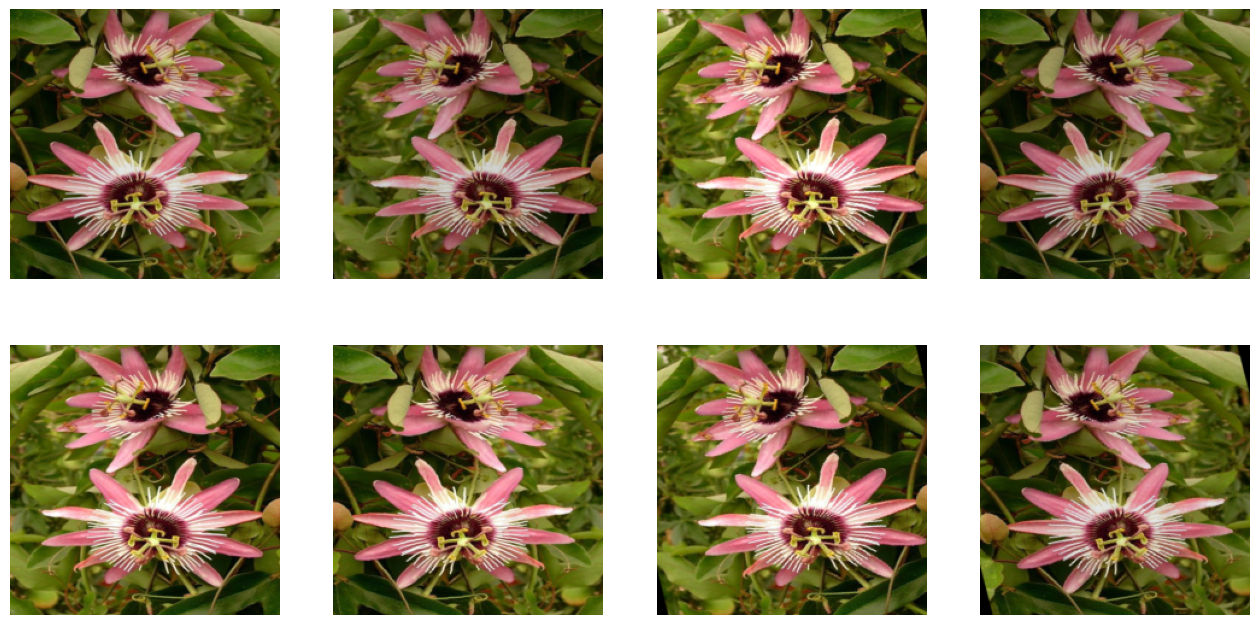

In [40]:
# Display 8 augmented versions of the selected image to see the transformations.
visualize_augmentations(dataset_augmented, idx=sel_idx, num_versions=8)

In [41]:
# Now apply the specific augmentation pipeline to the training subset
# Val and test subsets remain with the base preprocessing transform applied earlier
train_dataset = SubsetWithTransform(train_subset, transform=augmentation_transform)

In [42]:
print(train_dataset.transform)
print(val_dataset.transform)
print(test_dataset.transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### Error Handling

In [45]:
class RobustFlowerDataset(Dataset):
    """
    A custom dataset class with robust error handling for loading images.

    This class is designed to gracefully handle issues with individual data
    samples, such as corrupted files or incorrect formats. It logs any errors
    and attempts to load a different sample instead of crashing.
    """
    def __init__(self, root_dir, transform=None):
        """
        Initializes the dataset object.

        Args:
            root_dir (str): The root directory where the dataset is stored.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        # Store the root directory path.
        self.root_dir = root_dir
        # Construct the full path to the image directory.
        self.img_dir = os.path.join(root_dir, "jpg")
        # Store the optional transformations.
        self.transform = transform
        # Load and process the labels from the corresponding file.
        self.labels = self.load_and_correct_labels()
        # Initialize a list to keep track of any errors encountered.
        self.error_logs = []

    def __getitem__(self, idx):
        """
        Retrieves a sample, handling errors by trying the next available item.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            image (PIL.Image.Image or torch.Tensor): The processed image data.
            label (int): The corresponding label for the image.
        """
        # Loop to attempt loading a valid sample, preventing an infinite loop.
        for attempt in range(len(self)):
            # Attempt to load and process the sample.
            try:
                # Retrieve the image using the helper method.
                image = self.retrieve_image(idx)
                # Check if a transform has been provided.
                if self.transform:
                    # Apply the transform to the image.
                    image = self.transform(image)
                # Get the label for the current index.
                label = self.labels[idx]
                # Return the valid image and its corresponding label.
                return image, label
            # Catch any exception that occurs during the process.
            except Exception as e:
                # Log the error with its index and message.
                self.log_error(idx, e)
                # Move to the next index, wrapping around if necessary.
                idx = (idx + 1) % len(self)

    def __len__(self):
        """
        Returns the total number of samples in the dataset.

        Returns:
            total_samples (int): The total number of items in the dataset.
        """
        # The total number of samples is the number of labels.
        total_samples = len(self.labels)
        # Return the calculated length.
        return total_samples

    def retrieve_image(self, idx):
        """
        Loads and validates a single image from disk.

        Args:
            idx (int): The index of the image to load.

        Returns:
            image (PIL.Image.Image): The validated and loaded image object.
        """
        # Construct the image filename based on the index.
        img_name = f"image_{idx+1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.img_dir, img_name)
        # Open the image file to check its integrity without loading fully.
        with Image.open(img_path) as img:
            # Perform a quick verification of the file's structure.
            img.verify()
        # Re-open the image file after successful verification.
        image = Image.open(img_path)
        # Fully load the image data into memory.
        image.load()
        # Check if the image dimensions are below a minimum threshold.
        if image.size[0] < 32 or image.size[1] < 32:
            # Raise an error for images that are too small.
            raise ValueError(f"Image too small: {image.size}")
        # Check if the image is not in the RGB color mode.
        if image.mode != "RGB":
            # Convert the image to RGB.
            image = image.convert("RGB")
        # Return the fully loaded and validated image.
        return image

    def load_and_correct_labels(self):
        """
        Loads labels from a file and adjusts them.

        Returns:
            labels (numpy.ndarray): An array of zero-indexed integer labels.
        """
        # Load the file containing the labels.
        self.labels_mat = scipy.io.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extract the labels array and correct for zero-based indexing.
        labels = self.labels_mat["labels"][0] - 1
        # Truncate the dataset to the first 10 labels for quick testing.
        labels = labels[:10]
        # Return the processed labels.
        return labels

    def log_error(self, idx, e):
        """
        Records the details of an error encountered during data loading.

        Args:
            idx (int): The index of the problematic sample.
            e (Exception): The exception object that was raised.
        """
        # Construct the filename of the problematic image.
        img_name = f"image_{idx + 1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.img_dir, img_name)
        # Append a dictionary with error details to the log.
        self.error_logs.append(
            {
                "index": idx,
                "error": str(e),
                "path": img_path if "img_path" in locals() else "unknown",
            }
        )
        # Print a warning to the console about the skipped image.
        print(f"Warning: Skipping corrupted image {idx}: {e}")

    def get_error_summary(self):
        """
        Prints a summary of all errors encountered during dataset processing.
        """
        # Check if the error log is empty.
        if not self.error_logs:
            # Print a message indicating the dataset is clean.
            print("No errors encountered - dataset is clean!")
        else:
            # Print the total number of problematic images found.
            print(f"\nEncountered {len(self.error_logs)} problematic images:")
            # Iterate through the first few logged errors.
            for error in self.error_logs[:5]:
                # Print the details of an individual error.
                print(f"  Index {error['index']}: {error['error']}")
            # Check if there are more errors than were displayed.
            if len(self.error_logs) > 5:
                # Print a summary of the remaining errors.
                print(f"  ... and {len(self.error_logs) - 5} more")

In [46]:
# Define the path to the directory containing the corrupted dataset.
corrupted_dataset_path = './corrupted_flower_data'

# Initialize the robust dataset handler with the path to the corrupted data.
robust_dataset = RobustFlowerDataset(corrupted_dataset_path)

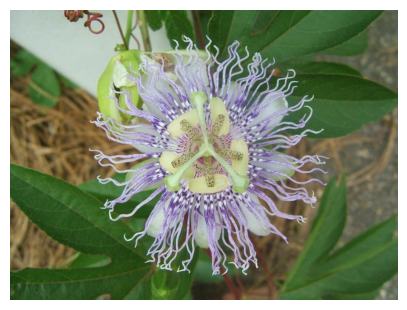

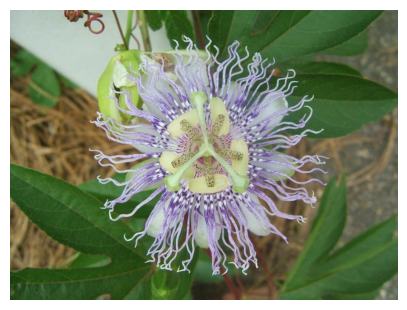

In [47]:
# Set the index to a known corrupted image. Image 2 is tiny
idx = 2

# Attempt to retrieve the image; the robust dataset will skip the bad one and return the next.
img, label = robust_dataset[idx]

# Plot the retrieved image, which should be the one following the corrupted one.
helper_utils.plot_img(img)

# Explicitly retrieve the next image in the sequence to verify.
next_img, next_label = robust_dataset[idx + 1]

# Plot the next image; it should be identical to the one above.
helper_utils.plot_img(next_img)

In [48]:
# Set the index to a known grayscale image.
# Image 4 is corrupted (grayscale)
idx = 4

# Reconstruct the path to the original image file.
original_img_path = os.path.join(robust_dataset.img_dir, f"image_{idx + 1:05d}.jpg")
# Open the original image directly to check its mode before correction.
original_img = Image.open(original_img_path)
# Print the mode of the original, uncorrected image.
# Prints 'L' for 8-bit grayscale. A standard color image would be 'RGB'.
print(f"Mode of the original image file: {original_img.mode}")  

Mode of the original image file: L


Mode of the corrected image: RGB


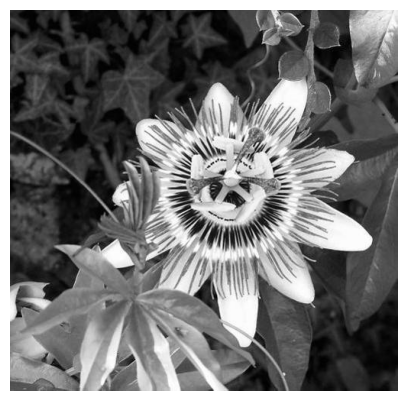

In [49]:
# Retrieve the image; the robust loader should automatically convert it to RGB.
img, label = robust_dataset[idx]

# Plot the image to visually confirm it's now in color.
helper_utils.plot_img(img)

# Print the image's mode to confirm it has been corrected to 'RGB'.
print(f"Mode of the corrected image: {img.mode}")

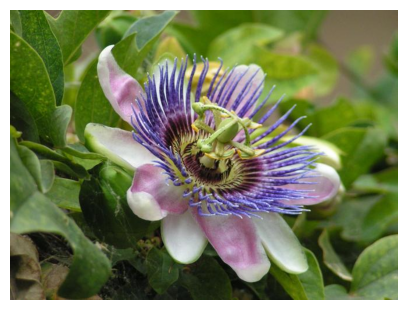

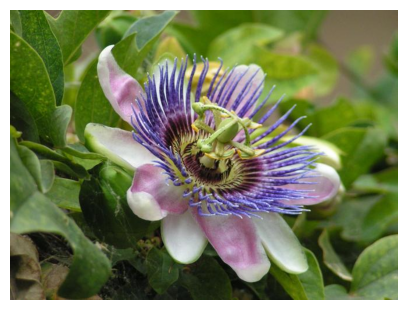

In [50]:
# Set the index to a known corrupted or unreadable image.
idx = 6

# Attempt to retrieve the image; the robust loader should skip the corrupted file and return the next one.
robust_img = robust_dataset[idx][0]

# Plot the retrieved image, which should be the sample from the next index (7).
helper_utils.plot_img(robust_img)

# Explicitly retrieve the next image in the sequence to verify the fallback logic.
# Check next image to ensure it's correct
next_img, next_label = robust_dataset[idx + 1]

# Plot the next image; it should be identical to the one above, confirming the skip.
helper_utils.plot_img(next_img)

In [51]:
# Display the summary of any corrupted or problematic images found during loading.
robust_dataset.get_error_summary()


Encountered 2 problematic images:
  Index 2: Image too small: (20, 20)
  Index 6: cannot identify image file './corrupted_flower_data\\jpg\\image_00007.jpg'


In [52]:
class MonitoredDataset(RobustFlowerDataset):
    """
    Extends a robust dataset class to add performance monitoring.

    This class tracks metrics such as how frequently each image is accessed,
    how long each access takes, and which images are never loaded. It provides
    a summary of these statistics to help diagnose data pipeline issues.
    """
    def __init__(self, *args, **kwargs):
        """
        Initializes the monitored dataset object.

        Args:
            *args (tuple): Variable length argument list passed to the parent class.
            **kwargs (dict): Arbitrary keyword arguments passed to the parent class.
        """
        # Initialize the parent class with all provided arguments.
        super().__init__(*args, **kwargs)
        # Initialize a dictionary to count how many times each index is accessed.
        self.access_counts = {}
        # Initialize a list to store the load time for each access.
        self.load_times = []

    def __getitem__(self, idx):
        """
        Retrieves a sample while monitoring access counts and load times.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            result (tuple): The data sample (e.g., image and label) from the parent class.
        """
        # Import the time module for timing operations.
        import time
        # Record the start time of the operation.
        start_time = time.time()
        # Increment the access count for the given index.
        self.access_counts[idx] = self.access_counts.get(idx, 0) + 1
        # Call the parent class's method to load the data.
        result = super().__getitem__(idx)
        # Calculate the total time taken to load the sample.
        load_time = time.time() - start_time
        # Append the calculated load time to the list.
        self.load_times.append(load_time)
        # Check if the load time exceeds a certain threshold.
        if load_time > 1.0:
            # Print a warning if a slow load time is detected.
            print(f"⚠️ Slow load: Image {idx} took {load_time:.2f}s")
        # Return the loaded sample from the parent class.
        return result

    def print_stats(self):
        """
        Prints a summary of the dataset's access statistics and performance.
        """
        # Print a header for the statistics report.
        print("\n=== Pipeline Statistics ===")
        # Display the total number of images in the dataset.
        print(f"Total images: {len(self)}")
        # Display the number of unique images that were accessed.
        print(f"Unique images accessed: {len(self.access_counts)}")
        # Display the total number of errors logged by the parent class.
        print(f"Errors encountered: {len(self.error_logs)}")
        # Check if any load times have been recorded.
        if self.load_times:
            # Calculate the average load time.
            avg_time = sum(self.load_times) / len(self.load_times)
            # Find the maximum (slowest) load time.
            max_time = max(self.load_times)
            # Print the average load time in milliseconds.
            print(f"Average load time: {avg_time*1000:.1f} ms")
            # Print the slowest load time in milliseconds.
            print(f"Slowest load: {max_time*1000:.1f} ms")
        # Create a set of all possible indices in the dataset.
        all_indices = set(range(len(self)))
        # Create a set of all indices that were actually accessed.
        accessed_indices = set(self.access_counts.keys())
        # Find the set of indices that were never accessed.
        never_accessed = all_indices - accessed_indices
        # Check if there are any images that were never loaded.
        if never_accessed:
            # Print a warning message with the count of never-accessed images.
            print(f"\n⚠️ WARNING: {len(never_accessed)} images were never loaded!")
            # Show a few examples of the indices that were never accessed.
            print(f"   Examples: {list(never_accessed)[:5]}")

In [53]:
# Initialize the monitored dataset with the path to the potentially corrupted data.
monitored_dataset = MonitoredDataset(corrupted_dataset_path)

# Loop through every index in the dataset to simulate a full pass.
# Iterate through the dataset to trigger monitoring
for idx in range(len(monitored_dataset)):
    # Access the sample at the current index to trigger the monitoring and error-handling logic.
    img, label = monitored_dataset[idx]

In [54]:
# Print the statistics
monitored_dataset.print_stats()


=== Pipeline Statistics ===
Total images: 10
Unique images accessed: 10
Errors encountered: 2
Average load time: 2.1 ms
Slowest load: 9.0 ms
